Coastal upwelling occurs when persistent surface winds blow parallel to the coastline. Combined with the Coriolis effect, this wind forcing drives Ekman transport, which pushes surface water offshore. This mass divergence at the coast creates a deficit, causing deeper, colder, and nutrient-rich ocean layers to rise to the surface to replace the displaced water.

In this notebook, we will download and analyze data from the Copernicus Marine Service to observe the upwelling phenomenon along the California coast. We will visualize this physical process using different variables, including:

    Wind Velocity 

    Sea Level Anomaly (SLA)

    Sea Surface Temperature (SST)

    Chlorophyll Concentration

Data Download

To download data from the Copernicus Marine Service, you first need to create an account here: 
[Copernicus Marine Registration](https://marine.copernicus.eu/register-copernicus-marine-service)

By importing the `copernicusmarine` Python toolbox, we can interface directly with their servers to download customized subsets of global ocean data and visualize product metadata.

In [96]:
import copernicusmarine

In [97]:
# By running the following cell, we can directly download the data subset. We need to use our credentials.

# 1. Wind Data
# We will focus on the California coast, extracting one full year of data to capture the entire seasonal cycle and observe how the upwelling forcing 
# changes throughout the year.

copernicusmarine.subset(
    dataset_id="cmems_obs-wind_glo_phy_my_l4_0.125deg_PT1H",
    variables=["northward_wind", "eastward_wind"],
    minimum_longitude=-133,
    maximum_longitude=-114,
    minimum_latitude=30,
    maximum_latitude=41,
    start_datetime="2024-01-01T00:00:00",
    end_datetime="2025-01-01T00:00:00",
    output_directory="data"
)

INFO - 2026-10-05T10:17:09Z - Selected dataset version: "202211"
INFO - 2026-10-05T10:17:09Z - Selected dataset part: "default"
INFO - 2026-10-05T10:17:13Z - Starting download. Please wait...


  0%|          | 0/3442 [00:00<?, ?it/s]

INFO - 2026-10-05T10:23:29Z - Successfully downloaded to data/cmems_obs-wind_glo_phy_my_l4_0.125deg_PT1H_multi-vars_132.94W-114.06W_30.06N-40.94N_2024-01-01-2025-01-01.nc


ResponseSubset(file_path=PosixPath('data/cmems_obs-wind_glo_phy_my_l4_0.125deg_PT1H_multi-vars_132.94W-114.06W_30.06N-40.94N_2024-01-01-2025-01-01.nc'), output_directory=PosixPath('data'), filename='cmems_obs-wind_glo_phy_my_l4_0.125deg_PT1H_multi-vars_132.94W-114.06W_30.06N-40.94N_2024-01-01-2025-01-01.nc', file_size=448.517427480916, data_transfer_size=3791.6365190839697, variables=['northward_wind', 'eastward_wind'], coordinates_extent=[GeographicalExtent(minimum=-132.9375, maximum=-114.0625, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=30.0625, maximum=40.9375, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2024-01-01T00:00:00+00:00', maximum='2025-01-01T00:00:00+00:00', unit='iso8601', coordinate_id='time')], status='000', message='The request was successful.', file_status='DOWNLOADED')

In [98]:
# 2. Sea Level Anomaly (SLA) Data

# During upwelling, we expect to see a localized drop in sea level near the coast. This depression is caused by two factors:
# 1. Mass Divergence: Ekman transport physically moves water volume offshore.
# 2. The Steric Effect: The deep, upwelled water replacing it is much colder and denser, meaning it occupies less physical volume than warm surface water.

copernicusmarine.subset(
dataset_id="cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D",
 variables=["sla"],
 minimum_longitude=-133,
 maximum_longitude=-114,
 minimum_latitude=30,
 maximum_latitude=41,
start_datetime="2024-01-01T00:00:00",
 end_datetime="2025-01-01T00:00:00",
output_directory = "data"
)

INFO - 2026-10-05T10:23:29Z - Selected dataset version: "202411"
INFO - 2026-10-05T10:23:29Z - Selected dataset part: "default"
INFO - 2026-10-05T10:23:32Z - Starting download. Please wait...


  0%|          | 0/235 [00:00<?, ?it/s]

INFO - 2026-10-05T10:23:44Z - Successfully downloaded to data/cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_sla_132.94W-114.06W_30.06N-40.94N_2024-01-01-2025-01-01.nc


ResponseSubset(file_path=PosixPath('data/cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_sla_132.94W-114.06W_30.06N-40.94N_2024-01-01-2025-01-01.nc'), output_directory=PosixPath('data'), filename='cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_sla_132.94W-114.06W_30.06N-40.94N_2024-01-01-2025-01-01.nc', file_size=18.7496106870229, data_transfer_size=252.18540458015266, variables=['sla'], coordinates_extent=[GeographicalExtent(minimum=-132.9375, maximum=-114.0625, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=30.0625, maximum=40.9375, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2024-01-01T00:00:00+00:00', maximum='2025-01-01T00:00:00+00:00', unit='iso8601', coordinate_id='time')], status='000', message='The request was successful.', file_status='DOWNLOADED')

In [99]:
# 3. Sea Surface Temperature (SST) Data

copernicusmarine.subset(
dataset_id="METOFFICE-GLO-SST-L4-REP-OBS-SST", 
 variables=["analysed_sst"],
 minimum_longitude=-133,
 maximum_longitude=-114,
 minimum_latitude=30,
 maximum_latitude=41,
start_datetime="2024-01-01T00:00:00",
 end_datetime="2025-01-01T00:00:00",
output_directory = "data"
)

INFO - 2026-10-05T10:23:44Z - Selected dataset version: "202003"
INFO - 2026-10-05T10:23:44Z - Selected dataset part: "default"
INFO - 2026-10-05T10:23:47Z - Starting download. Please wait...


  0%|          | 0/725 [00:00<?, ?it/s]

INFO - 2026-10-05T10:24:00Z - Successfully downloaded to data/METOFFICE-GLO-SST-L4-REP-OBS-SST_analysed_sst_132.98W-114.03W_30.02N-40.97N_2024-01-01-2025-01-01.nc


ResponseSubset(file_path=PosixPath('data/METOFFICE-GLO-SST-L4-REP-OBS-SST_analysed_sst_132.98W-114.03W_30.02N-40.97N_2024-01-01-2025-01-01.nc'), output_directory=PosixPath('data'), filename='METOFFICE-GLO-SST-L4-REP-OBS-SST_analysed_sst_132.98W-114.03W_30.02N-40.97N_2024-01-01-2025-01-01.nc', file_size=58.564908396946564, data_transfer_size=2031.3893129770993, variables=['analysed_sst'], coordinates_extent=[GeographicalExtent(minimum=-132.97500610351562, maximum=-114.0250015258789, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=30.024999618530273, maximum=40.974998474121094, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2024-01-01T00:00:00+00:00', maximum='2025-01-01T00:00:00+00:00', unit='iso8601', coordinate_id='time')], status='000', message='The request was successful.', file_status='DOWNLOADED')

In [100]:
# 4. Chlorophyll Concentration Data

copernicusmarine.subset(
dataset_id="cmems_mod_glo_bgc-pft_anfc_0.25deg_P1D-m", 
 variables=["chl"],
 minimum_longitude=-133,
 maximum_longitude=-114,
 minimum_latitude=30,
 maximum_latitude=41,
start_datetime="2024-01-01T00:00:00",
 end_datetime="2025-01-01T00:00:00",
 minimum_depth= 0,
 maximum_depth= 0.5,
output_directory = "data"
)

INFO - 2026-10-05T10:24:01Z - Selected dataset version: "202311"
INFO - 2026-10-05T10:24:01Z - Selected dataset part: "default"
WARNING - 2026-10-05T10:24:03Z - Some of your subset selection [0, 0.5] for the depth dimension exceed the dataset coordinates [0.4940253794193268, 5727.91650390625]
INFO - 2026-10-05T10:24:04Z - Starting download. Please wait...


  0%|          | 0/13 [00:00<?, ?it/s]

INFO - 2026-10-05T10:24:05Z - Successfully downloaded to data/cmems_mod_glo_bgc-pft_anfc_0.25deg_P1D-m_chl_133.00W-114.00W_30.00N-41.00N_0.49m_2024-01-01-2025-01-01.nc


ResponseSubset(file_path=PosixPath('data/cmems_mod_glo_bgc-pft_anfc_0.25deg_P1D-m_chl_133.00W-114.00W_30.00N-41.00N_0.49m_2024-01-01-2025-01-01.nc'), output_directory=PosixPath('data'), filename='cmems_mod_glo_bgc-pft_anfc_0.25deg_P1D-m_chl_133.00W-114.00W_30.00N-41.00N_0.49m_2024-01-01-2025-01-01.nc', file_size=4.866645038167939, data_transfer_size=65.42656488549618, variables=['chl'], coordinates_extent=[GeographicalExtent(minimum=-133.0, maximum=-114.0, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=30.0, maximum=41.0, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2024-01-01T00:00:00+00:00', maximum='2025-01-01T00:00:00+00:00', unit='iso8601', coordinate_id='time'), GeographicalExtent(minimum=0.4940253794193268, maximum=0.4940253794193268, unit='m', coordinate_id='depth')], status='000', message='The request was successful.', file_status='DOWNLOADED')

In [101]:
# We can now load and see the content of the downloaded subsets

import xarray as xr

# Define the paths to the file
path_wind = 'data/cmems_obs-wind_glo_phy_my_l4_0.125deg_PT1H_multi-vars_132.94W-114.06W_30.06N-40.94N_2024-01-01-2025-01-01.nc'
data_wind = xr.open_dataset(path_wind)

path_sla = 'data/cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_sla_132.94W-114.06W_30.06N-40.94N_2024-01-01-2025-01-01.nc'
data_sla = xr.open_dataset(path_sla)

path_temp = 'data/METOFFICE-GLO-SST-L4-REP-OBS-SST_analysed_sst_132.98W-114.03W_30.02N-40.97N_2024-01-01-2025-01-01.nc'
data_temp = xr.open_dataset(path_temp)

path_chl = 'data/cmems_mod_glo_bgc-pft_anfc_0.25deg_P1D-m_chl_133.00W-114.00W_30.00N-41.00N_0.49m_2024-01-01-2025-01-01.nc'
data_chl = xr.open_dataset(path_chl)

# Inspect the content of the file
#data_sla
#data_wind
#data_temp
#data_chl

In [102]:
# Import libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

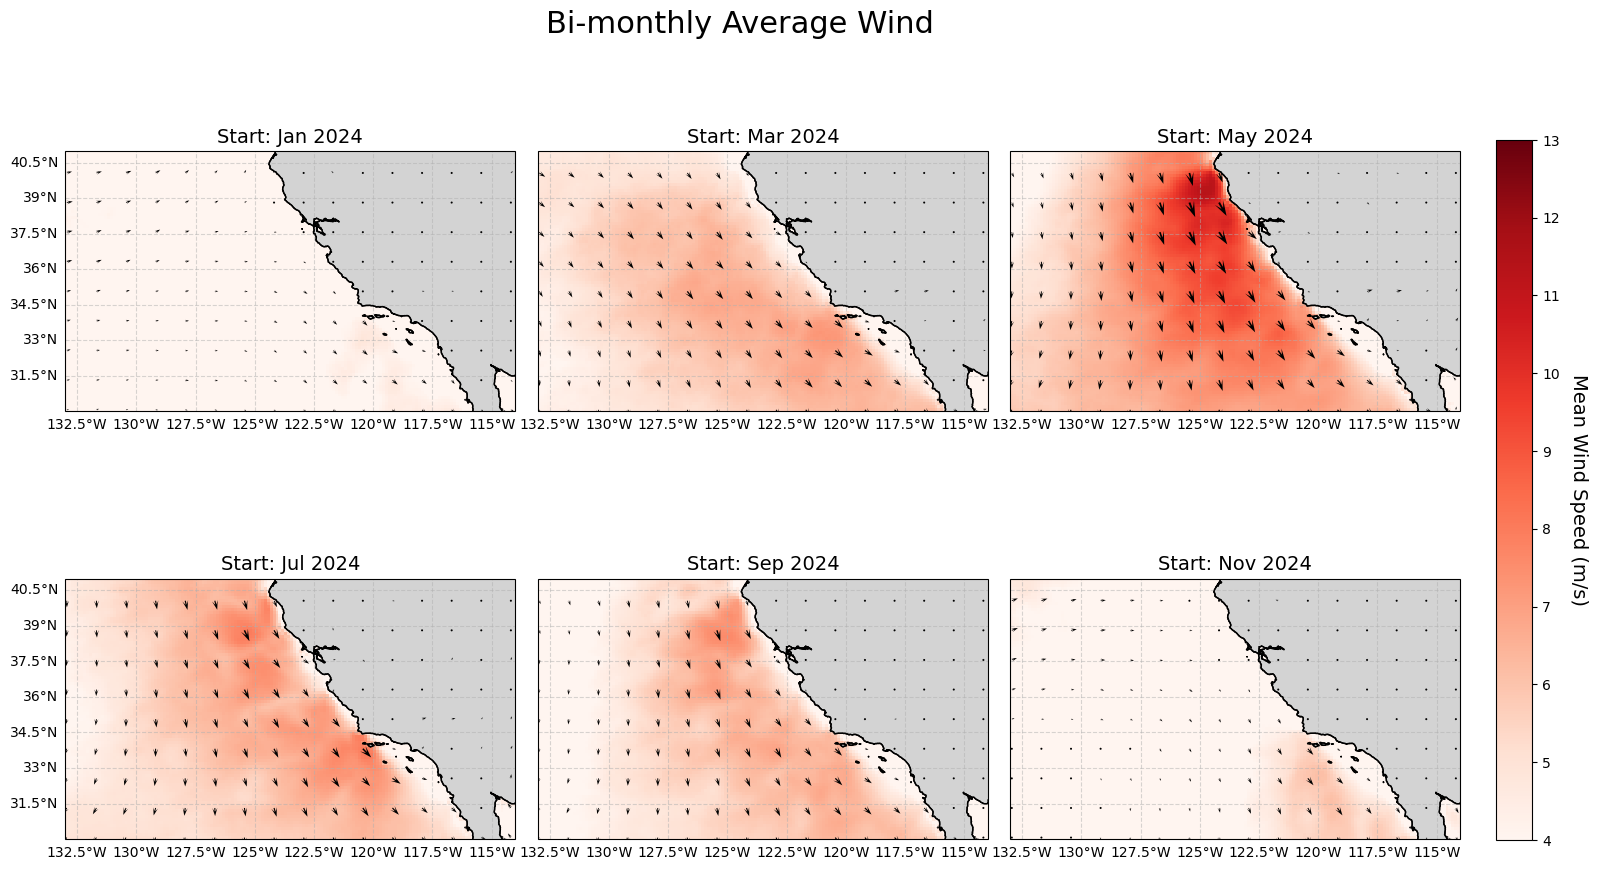

In [103]:
# To determine if we are in favorable conditions for coastal upwelling throughout the year, we will average the wind components over time, 
# splitting our one-year dataset into six bi-monthly averages.

# Recall from the lecture slides on Ekman Theory:
#   Ekman Transport: The mean water mass transport within the surface Ekman layer is directed 90° to the right of the wind direction 
#   in the Northern Hemisphere.
#   Coastal Upwelling/Downwelling: surface water flow against/away from the coast.

# 1. Resample data into 2-month chunks
data_2m = data_wind.resample(time='2MS').mean()

# Calculate means 
u_mean = data_2m['eastward_wind'].squeeze()
v_mean = data_2m['northward_wind'].squeeze()
wind_speed = np.sqrt(u_mean**2 + v_mean**2)

# Extract coordinates 
lon, lat = data_wind['longitude'].values, data_wind['latitude'].values
lon_2d, lat_2d = np.meshgrid(lon, lat)
step = 10

# 2. Prepare the grid
f, axs = plt.subplots(2, 3, figsize=(18, 10), subplot_kw={'projection': ccrs.PlateCarree()})
f.subplots_adjust(hspace=0.25, wspace=0.05)
axs = axs.flatten()

# 3. Loop through the 6 time chunks
for i in range(6):
    ax = axs[i]
    
    ax.coastlines(zorder=3)
    ax.add_feature(cfeature.LAND, zorder=2, edgecolor='k', facecolor='lightgray')
    ax.set_extent([-133, -114, 30, 41], crs=ccrs.PlateCarree())
    
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linestyle='--', alpha=0.5)
    gl.right_labels = gl.top_labels = False
    if i not in [0, 3]: gl.left_labels = False 
        
    # Plot background wind speed
    im = ax.pcolormesh(lon, lat, wind_speed.isel(time=i).values, 
                       vmin=4, vmax=13, cmap='Reds', transform=ccrs.PlateCarree(), zorder=1)
                       
    # Plot wind direction vectors
    ax.quiver(lon_2d[::step, ::step], lat_2d[::step, ::step],
              u_mean.isel(time=i).values[::step, ::step], 
              v_mean.isel(time=i).values[::step, ::step],
              transform=ccrs.PlateCarree(), headlength=8, headwidth=5, scale=300, zorder=4)
              
    date_str = pd.to_datetime(wind_speed.time[i].values).strftime('%b %Y')
    ax.set_title(f'Start: {date_str}', fontsize=14)

f.suptitle('Bi-monthly Average Wind', fontsize=22, y=0.98)

cbar_ax = f.add_axes([0.92, 0.15, 0.02, 0.7]) 
cbar = f.colorbar(im, cax=cbar_ax)
cbar.set_label('Mean Wind Speed (m/s)', rotation=270, fontsize=14, labelpad=20)

plt.show()

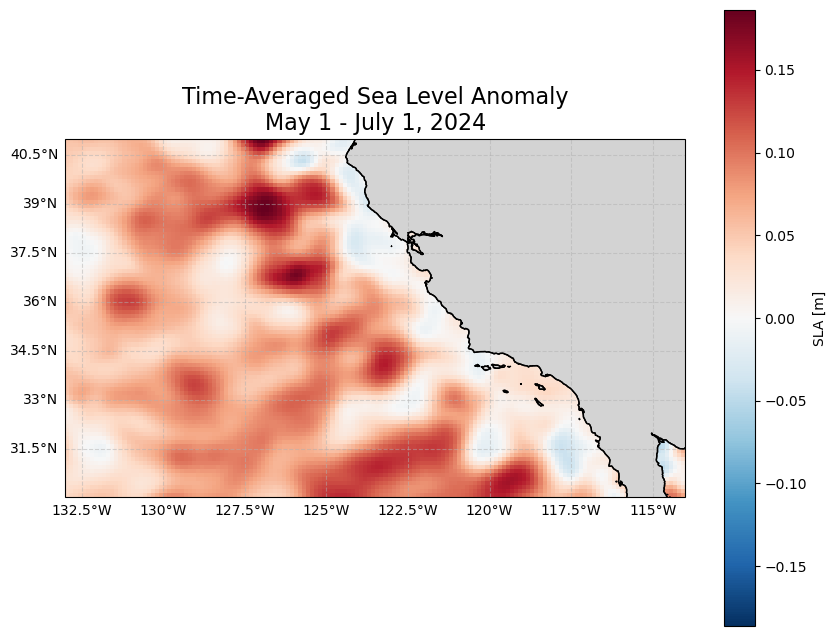

In [104]:
# From the previous step we observe that the wind always blows southwards, parallel to the coast. This means that coastal upwelling always happens.
# However from May to July the winds are the strongest. Here the upwelling phenomenon will be more visible, therefore we select this time interval 
# for the further analysis.

# We plot here the SLA in the region averaged in the selected months:
# What do we expect to see? Coastal SLA lower than offshore. Why? Wind drives surface water offshore.--> The coast loses volume, and cold, dense 
# water rises to fill the gap --> The combination of missing mass and increased density causes the sea surface to sit closer to the ocean floor,
# resulting in a lower SLA.

# 1. Filter the dates and calculate the time-averaged SLA
sla = data_sla['sla'].sel(time=slice('2024-05-01', '2024-07-01')).mean(dim='time').squeeze()

# 2. Set up figure
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

sla.plot.pcolormesh(
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    cbar_kwargs={'label': 'SLA [m]'}
)

# 3. Add map features
ax.coastlines(zorder=3)
ax.add_feature(cfeature.LAND, zorder=2, edgecolor='k', facecolor='lightgray')
ax.set_extent([-133, -114, 30, 41], crs=ccrs.PlateCarree())

gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.right_labels = False
gl.top_labels = False

ax.set_title('Time-Averaged Sea Level Anomaly\nMay 1 - July 1, 2024', fontsize=16)

plt.show()

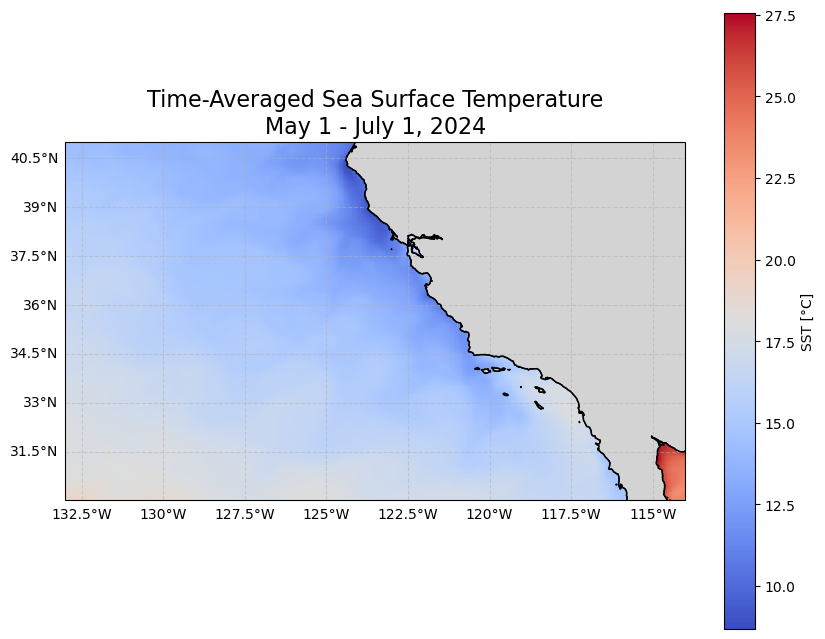

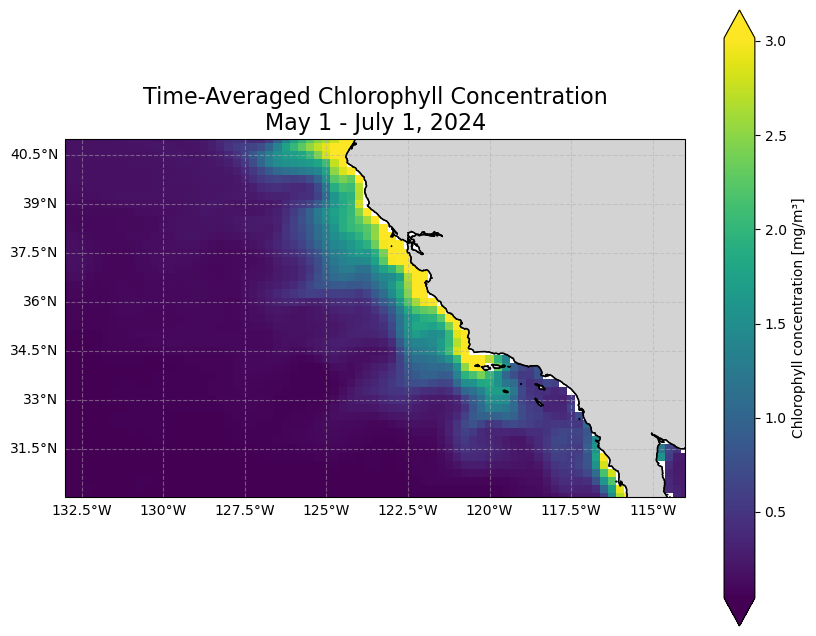

In [105]:
# Now we can plot the Sea Surface Temperature (SST) and Chlorophyll concentration for the same time period. 
# Because the upwelled water comes from the deep ocean, we expect to see a band of cold water along the coastline.
# Since this deep water is also packed with nutrients, we should see a corresponding high chlorophyll concentrations in the same coastal band.

# 1. SEA SURFACE TEMPERATURE (SST)

# Filter dates, calculate time-average, and convert from Kelvin to Celsius
sst = data_temp['analysed_sst'].sel(time=slice('2024-05-01', '2024-07-01')).mean(dim='time').squeeze() - 273.15

# Set up figure 
fig1, ax1 = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

sst.plot.pcolormesh(
    ax=ax1, 
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    cbar_kwargs={'label': 'SST [°C]'}
)

# Add map features
ax1.coastlines(zorder=3)
ax1.add_feature(cfeature.LAND, zorder=2, edgecolor='k', facecolor='lightgray')
ax1.set_extent([-133, -114, 30, 41], crs=ccrs.PlateCarree())

gl1 = ax1.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl1.right_labels = False
gl1.top_labels = False

ax1.set_title('Time-Averaged Sea Surface Temperature\nMay 1 - July 1, 2024', fontsize=16)
plt.show() 


# 2. CHLOROPHYLL CONCENTRATION

# Filter dates and calculate time-average
chl = data_chl['chl'].sel(time=slice('2024-05-01', '2024-07-01')).mean(dim='time').squeeze()

# Set up figure
fig2, ax2 = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

chl.plot.pcolormesh(
    ax=ax2, 
    transform=ccrs.PlateCarree(),
    cmap='viridis',
    robust=True, 
    cbar_kwargs={'label': 'Chlorophyll concentration [mg/m³]'}
)

# Add map features
ax2.coastlines(zorder=3)
ax2.add_feature(cfeature.LAND, zorder=2, edgecolor='k', facecolor='lightgray')
ax2.set_extent([-133, -114, 30, 41], crs=ccrs.PlateCarree())

gl2 = ax2.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl2.right_labels = False
gl2.top_labels = False

ax2.set_title('Time-Averaged Chlorophyll Concentration\nMay 1 - July 1, 2024', fontsize=16)
plt.show()

# Equatorial Upwelling

Along the equator in the Pacific Ocean, the Trade Winds blow consistently from east to west. As these winds drag the surface water westward, the Coriolis effect deflects the water:
    To the right (North) in the Northern Hemisphere.
    To the left (South) in the Southern Hemisphere.

This creates a massive divergence zone on the equator. As surface water is pulled apart to the north and south, cold, nutrient-rich deep water upwells to fill the void.

In [106]:
# 1. Equatorial Wind
copernicusmarine.subset(
    dataset_id="cmems_obs-wind_glo_phy_my_l4_0.125deg_PT1H",
    variables=["northward_wind", "eastward_wind"],
    minimum_longitude=-170,
    maximum_longitude=-90,
    minimum_latitude=-20,
    maximum_latitude=20,
    start_datetime="2024-05-01T00:00:00",
    end_datetime="2024-07-01T00:00:00",
    output_directory="data_equatorial"
)

# 2. Equatorial SLA
copernicusmarine.subset(
    dataset_id="cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D",
    variables=["sla"],
    minimum_longitude=-170,
    maximum_longitude=-90,
    minimum_latitude=-20,
    maximum_latitude=20,
    start_datetime="2024-08-01T00:00:00",
    end_datetime="2024-10-01T00:00:00",
    output_directory="data_equatorial"
)

# 3. Equatorial SST
copernicusmarine.subset(
    dataset_id="METOFFICE-GLO-SST-L4-REP-OBS-SST", 
    variables=["analysed_sst"],
    minimum_longitude=-170,
    maximum_longitude=-90,
    minimum_latitude=-20,
    maximum_latitude=20,
    start_datetime="2024-05-01T00:00:00",
    end_datetime="2024-07-01T00:00:00",
    output_directory="data_equatorial"
)

# 4. Equatorial Chlorophyll
copernicusmarine.subset(
    dataset_id="cmems_mod_glo_bgc-pft_anfc_0.25deg_P1D-m", 
    variables=["chl"],
    minimum_longitude=-170,
    maximum_longitude=-90,
    minimum_latitude=-20,
    maximum_latitude=20,
    start_datetime="2024-05-01T00:00:00",
    end_datetime="2024-07-01T00:00:00",
    minimum_depth=0,
    maximum_depth=0.5,
    output_directory="data_equatorial"
)

INFO - 2026-10-05T10:24:14Z - Selected dataset version: "202211"
INFO - 2026-10-05T10:24:14Z - Selected dataset part: "default"
INFO - 2026-10-05T10:24:19Z - Starting download. Please wait...


  0%|          | 0/5958 [00:00<?, ?it/s]

INFO - 2026-10-05T10:25:11Z - Successfully downloaded to data_equatorial/cmems_obs-wind_glo_phy_my_l4_0.125deg_PT1H_multi-vars_169.94W-90.06W_19.94S-19.94N_2024-05-01-2024-07-01.nc
INFO - 2026-10-05T10:25:11Z - Selected dataset version: "202411"
INFO - 2026-10-05T10:25:11Z - Selected dataset part: "default"
INFO - 2026-10-05T10:25:15Z - Starting download. Please wait...


  0%|          | 0/63 [00:00<?, ?it/s]

INFO - 2026-10-05T10:25:16Z - Successfully downloaded to data_equatorial/cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_sla_169.94W-90.06W_19.94S-19.94N_2024-08-01-2024-10-01.nc
INFO - 2026-10-05T10:25:16Z - Selected dataset version: "202003"
INFO - 2026-10-05T10:25:16Z - Selected dataset part: "default"
INFO - 2026-10-05T10:25:19Z - Starting download. Please wait...


  0%|          | 0/645 [00:00<?, ?it/s]

INFO - 2026-10-05T10:25:28Z - Successfully downloaded to data_equatorial/METOFFICE-GLO-SST-L4-REP-OBS-SST_analysed_sst_169.98W-90.03W_19.98S-19.98N_2024-05-01-2024-07-01.nc
INFO - 2026-10-05T10:25:29Z - Selected dataset version: "202311"
INFO - 2026-10-05T10:25:29Z - Selected dataset part: "default"
WARNING - 2026-10-05T10:25:31Z - Some of your subset selection [0, 0.5] for the depth dimension exceed the dataset coordinates [0.4940253794193268, 5727.91650390625]
INFO - 2026-10-05T10:25:32Z - Starting download. Please wait...


  0%|          | 0/63 [00:00<?, ?it/s]

INFO - 2026-10-05T10:25:34Z - Successfully downloaded to data_equatorial/cmems_mod_glo_bgc-pft_anfc_0.25deg_P1D-m_chl_170.00W-90.00W_20.00S-20.00N_0.49m_2024-05-01-2024-07-01.nc


ResponseSubset(file_path=PosixPath('data_equatorial/cmems_mod_glo_bgc-pft_anfc_0.25deg_P1D-m_chl_170.00W-90.00W_20.00S-20.00N_0.49m_2024-05-01-2024-07-01.nc'), output_directory=PosixPath('data_equatorial'), filename='cmems_mod_glo_bgc-pft_anfc_0.25deg_P1D-m_chl_170.00W-90.00W_20.00S-20.00N_0.49m_2024-05-01-2024-07-01.nc', file_size=12.24285496183206, data_transfer_size=232.05984732824427, variables=['chl'], coordinates_extent=[GeographicalExtent(minimum=-170.0, maximum=-90.0, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=-20.0, maximum=20.0, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2024-05-01T00:00:00+00:00', maximum='2024-07-01T00:00:00+00:00', unit='iso8601', coordinate_id='time'), GeographicalExtent(minimum=0.4940253794193268, maximum=0.4940253794193268, unit='m', coordinate_id='depth')], status='000', message='The request was successful.', file_status='DOWNLOADED')

In [107]:
path_wind_eq = 'data_equatorial/cmems_obs-wind_glo_phy_my_l4_0.125deg_PT1H_multi-vars_169.94W-90.06W_19.94S-19.94N_2024-05-01-2024-07-01.nc'
data_wind_eq = xr.open_dataset(path_wind_eq)

path_sla_eq = 'data_equatorial/cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_sla_169.94W-90.06W_19.94S-19.94N_2024-08-01-2024-10-01.nc'
data_sla_eq = xr.open_dataset(path_sla_eq)

path_temp_eq = 'data_equatorial/METOFFICE-GLO-SST-L4-REP-OBS-SST_analysed_sst_169.98W-90.03W_19.98S-19.98N_2024-05-01-2024-07-01.nc'
data_temp_eq = xr.open_dataset(path_temp_eq)

path_chl_eq = 'data_equatorial/cmems_mod_glo_bgc-pft_anfc_0.25deg_P1D-m_chl_170.00W-90.00W_20.00S-20.00N_0.49m_2024-05-01-2024-07-01.nc'
data_chl_eq = xr.open_dataset(path_chl_eq)

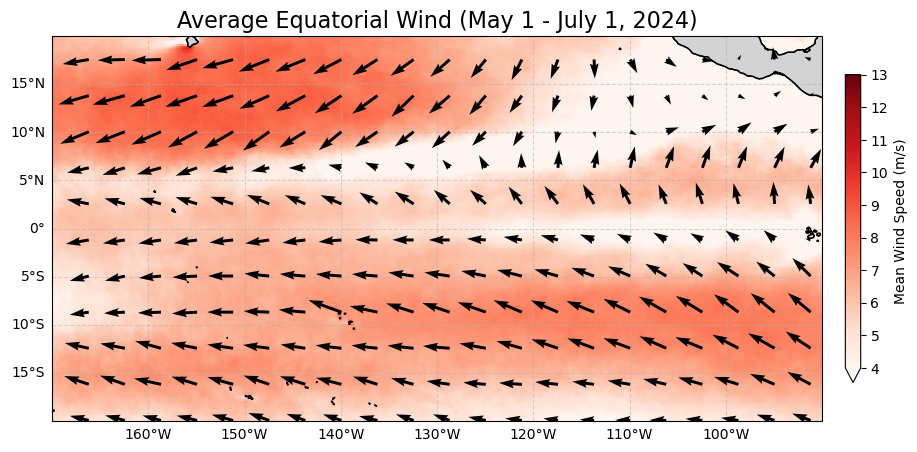

In [108]:
wind_mean = data_wind_eq.mean(dim='time').squeeze()
wind_speed = np.sqrt(wind_mean['eastward_wind']**2 + wind_mean['northward_wind']**2)

f, ax = plt.subplots(figsize=(15, 5), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-170, -90, -20, 20], crs=ccrs.PlateCarree())
ax.coastlines(zorder=3)
ax.add_feature(cfeature.LAND, zorder=2, edgecolor='k', facecolor='lightgray')

wind_speed.plot(ax=ax, vmin=4, vmax=13, cmap='Reds', 
                cbar_kwargs={'label': 'Mean Wind Speed (m/s)', 'pad': 0.02, 'shrink': 0.8})

# Changed the step size from 10 to 30 to thin out the quiver arrows
skip = wind_mean.isel(longitude=slice(None, None, 30), latitude=slice(None, None, 30))
ax.quiver(skip.longitude, skip.latitude, skip['eastward_wind'], skip['northward_wind'], 
          transform=ccrs.PlateCarree(), scale=200, zorder=4)

gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.right_labels = gl.top_labels = False
ax.set_title('Average Equatorial Wind (May 1 - July 1, 2024)', fontsize=16)

plt.show()

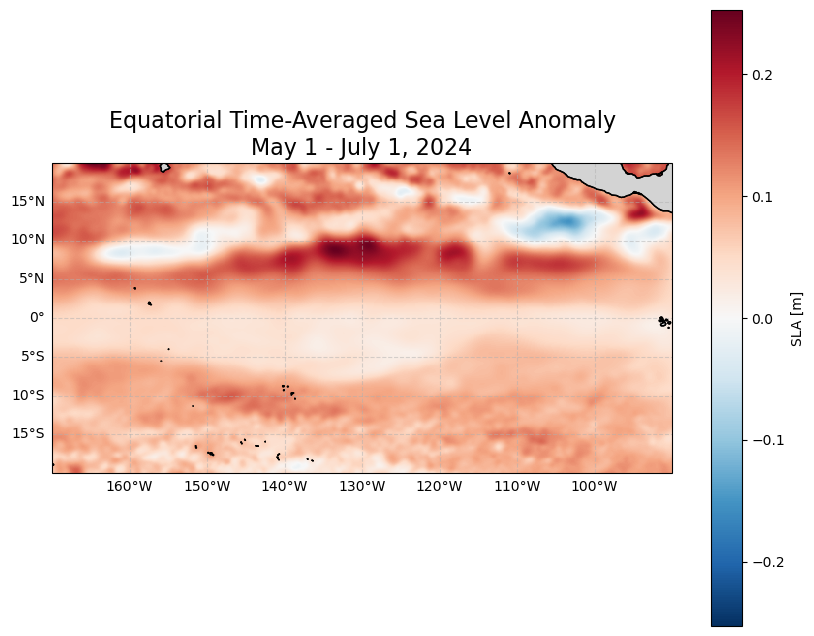

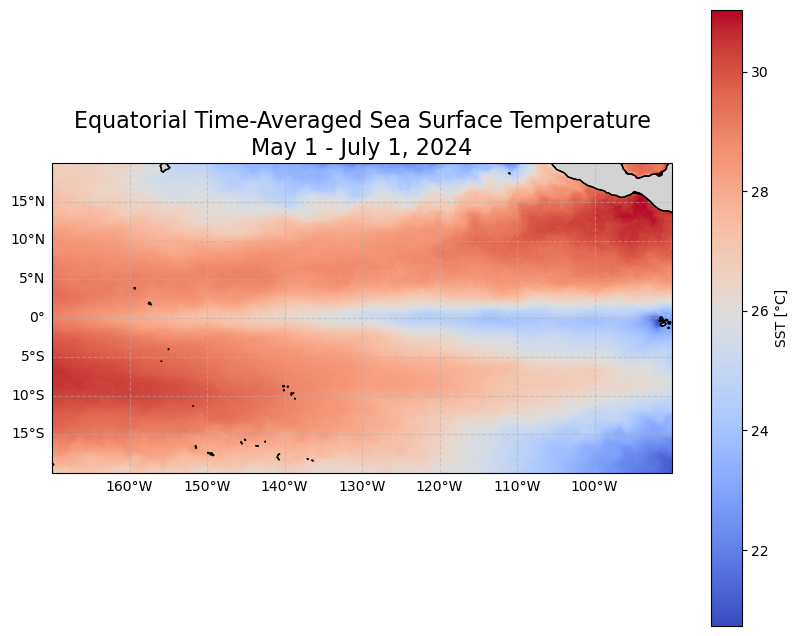

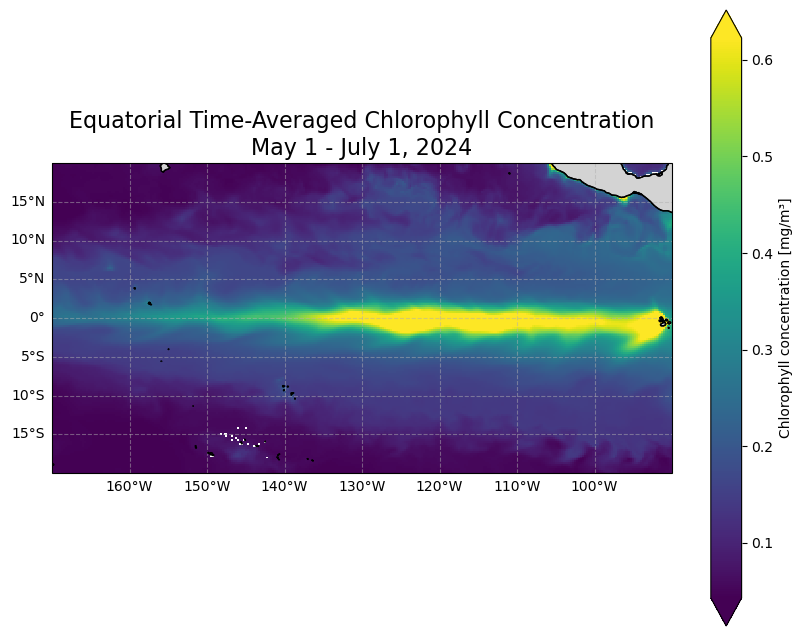

In [113]:
# 1. SEA LEVELANOMALY (SLA)

sla = data_sla_eq['sla'].mean(dim='time').squeeze()

fig1, ax1 = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

sla.plot.pcolormesh(
    ax=ax1, 
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    cbar_kwargs={'label': 'SLA [m]'}
)

ax1.coastlines(zorder=3)
ax1.add_feature(cfeature.LAND, zorder=2, edgecolor='k', facecolor='lightgray')
ax1.set_extent([-170, -90, -20, 20], crs=ccrs.PlateCarree())

gl1 = ax1.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl1.right_labels = False
gl1.top_labels = False

ax1.set_title('Equatorial Time-Averaged Sea Level Anomaly\nMay 1 - July 1, 2024', fontsize=16)

plt.show()

# 2. SEA SURFACE TEMPERATURE (SST)

sst = data_temp_eq['analysed_sst'].mean(dim='time').squeeze() - 273.15

fig2, ax2 = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

sst.plot.pcolormesh(
    ax=ax2, 
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    cbar_kwargs={'label': 'SST [°C]'}
)

ax2.coastlines(zorder=3)
ax2.add_feature(cfeature.LAND, zorder=2, edgecolor='k', facecolor='lightgray')
ax2.set_extent([-170, -90, -20, 20], crs=ccrs.PlateCarree())

gl2 = ax2.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl2.right_labels = False
gl2.top_labels = False

ax2.set_title('Equatorial Time-Averaged Sea Surface Temperature\nMay 1 - July 1, 2024', fontsize=16)
plt.show() 


# 3. CHLOROPHYLL CONCENTRATION

chl = data_chl_eq['chl'].mean(dim='time').squeeze()

fig3, ax3 = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

chl.plot.pcolormesh(
    ax=ax3, 
    transform=ccrs.PlateCarree(),
    cmap='viridis',
    robust=True, 
    cbar_kwargs={'label': 'Chlorophyll concentration [mg/m³]'}
)

ax3.coastlines(zorder=3)
ax3.add_feature(cfeature.LAND, zorder=2, edgecolor='k', facecolor='lightgray')
ax3.set_extent([-170, -90, -20, 20], crs=ccrs.PlateCarree())

gl3 = ax3.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl3.right_labels = False
gl3.top_labels = False

ax3.set_title('Equatorial Time-Averaged Chlorophyll Concentration\nMay 1 - July 1, 2024', fontsize=16)
plt.show()